# What Is Killing Our App's User Retention?
### End-to-End Data Analytics Project

**Problem Statement:**
> A mobile app has 100,000+ downloads but only 8% of users are still active after 30 days.
> The product team has data on user behaviour but no analysis.
> Goal: Identify exactly where users drop off, which features drive retention,
> and what the highest-value user profile looks like.

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, MySQL Workbench (SQL)

**Dataset:** Mobile Device Usage and User Behavior — Kaggle
- Download: https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset

---
## Project Structure
1. Import Libraries
2. Load and Understand Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Data Visualization
6. Final Dashboard (Combined Summary Figure)
7. Key Business Insights and Recommendations
8. Export Clean Data for MySQL Workbench

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Step 2 — Load and Understand the Dataset

**Download Steps:**
1. Go to: https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset
2. Download and extract the ZIP file
3. Place `user_behavior_dataset.csv` in the same folder as this notebook

In [2]:
df = pd.read_csv('user_behavior_dataset.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully.
Shape: 700 rows x 11 columns


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [3]:
print('Column Names:')
print(df.columns.tolist())

Column Names:
['User ID', 'Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class']


In [4]:
print('Data Types:')
print(df.dtypes)

Data Types:
User ID                         int64
Device Model                   object
Operating System               object
App Usage Time (min/day)        int64
Screen On Time (hours/day)    float64
Battery Drain (mAh/day)         int64
Number of Apps Installed        int64
Data Usage (MB/day)             int64
Age                             int64
Gender                         object
User Behavior Class             int64
dtype: object


In [5]:
# Statistical summary: count, mean, std, min, 25%, 50%, 75%, max
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [6]:
print('Missing Values Per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values Per Column:
User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

Total missing values: 0


In [7]:
print(f'Total duplicate rows: {df.duplicated().sum()}')

Total duplicate rows: 0


---
## Step 3 — Data Cleaning

Data cleaning removes or fixes incorrect, duplicate, and incomplete records.
Real-world data is always messy — this step ensures our analysis is accurate.

In [8]:
print(f'Original shape: {df.shape}')

# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f'After removing duplicates: {df.shape}')

# Drop rows where critical columns have missing values
critical_columns = [
    'User ID', 'App Usage Time (min/day)', 'Screen On Time (hours/day)',
    'Battery Drain (mAh/day)', 'Number of Apps Installed',
    'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'
]
df.dropna(subset=critical_columns, inplace=True)
print(f'After dropping missing critical values: {df.shape}')

Original shape: (700, 11)
After removing duplicates: (700, 11)
After dropping missing critical values: (700, 11)


In [9]:
# Standardize column names — remove spaces and special characters
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('/', '_')
)
print('Cleaned Column Names:')
print(df.columns.tolist())

Cleaned Column Names:
['User_ID', 'Device_Model', 'Operating_System', 'App_Usage_Time_min_day', 'Screen_On_Time_hours_day', 'Battery_Drain_mAh_day', 'Number_of_Apps_Installed', 'Data_Usage_MB_day', 'Age', 'Gender', 'User_Behavior_Class']


In [10]:
# Standardize text columns — fix whitespace and capitalization
df['Gender']           = df['Gender'].str.strip().str.capitalize()
df['Operating_System'] = df['Operating_System'].str.strip().str.capitalize()
df['Device_Model']     = df['Device_Model'].str.strip()

print('Unique Gender values    :', df['Gender'].unique())
print('Unique OS values        :', df['Operating_System'].unique())
print('Unique Behavior Classes :', sorted(df['User_Behavior_Class'].unique()))

Unique Gender values    : ['Male' 'Female']
Unique OS values        : ['Android' 'Ios']
Unique Behavior Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [11]:
# Remove outliers using IQR method
# IQR = Q3 - Q1. Values beyond 1.5*IQR from Q1 or Q3 are outliers.

def remove_outliers_iqr(dataframe, column):
    Q1    = dataframe[column].quantile(0.25)
    Q3    = dataframe[column].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

cols_to_clean = [
    'App_Usage_Time_min_day', 'Screen_On_Time_hours_day',
    'Battery_Drain_mAh_day',  'Data_Usage_MB_day'
]

for col in cols_to_clean:
    before = df.shape[0]
    df     = remove_outliers_iqr(df, col)
    print(f'{col}: removed {before - df.shape[0]} outliers')

print(f'\nFinal clean dataset shape: {df.shape}')

App_Usage_Time_min_day: removed 0 outliers
Screen_On_Time_hours_day: removed 0 outliers
Battery_Drain_mAh_day: removed 0 outliers
Data_Usage_MB_day: removed 0 outliers

Final clean dataset shape: (700, 11)


In [12]:
# Feature Engineering — create new columns from existing data

# Age Group classification
def classify_age(age):
    if age < 25:   return 'Gen Z (18-24)'
    elif age < 35: return 'Young Adult (25-34)'
    elif age < 50: return 'Adult (35-49)'
    else:          return 'Senior (50+)'

df['Age_Group'] = df['Age'].apply(classify_age)

# Engagement Level based on daily usage time
def classify_engagement(minutes):
    if minutes < 60:   return 'Low (<1hr)'
    elif minutes < 180: return 'Medium (1-3hrs)'
    elif minutes < 300: return 'High (3-5hrs)'
    else:               return 'Power User (5hrs+)'

df['Engagement_Level'] = df['App_Usage_Time_min_day'].apply(classify_engagement)

# Retention Risk flag — low usage + few apps = High Risk
df['Retention_Risk'] = np.where(
    (df['App_Usage_Time_min_day'] < 60) & (df['Number_of_Apps_Installed'] < 20),
    'High Risk',
    np.where(df['App_Usage_Time_min_day'] < 120, 'Medium Risk', 'Low Risk')
)

print('New columns: Age_Group, Engagement_Level, Retention_Risk')
df[['Age_Group', 'Engagement_Level', 'Retention_Risk']].head()

New columns: Age_Group, Engagement_Level, Retention_Risk


,Age_Group,Engagement_Level,Retention_Risk
0,Adult (35-49),Power User (5hrs+),Low Risk
1,Adult (35-49),High (3-5hrs),Low Risk
2,Adult (35-49),Medium (1-3hrs),Low Risk
3,Gen Z (18-24),High (3-5hrs),Low Risk
4,Young Adult (25-34),High (3-5hrs),Low Risk


In [13]:
print('=== CLEANED DATASET SUMMARY ===')
print(f'Total records  : {df.shape[0]}')
print(f'Total columns  : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')

=== CLEANED DATASET SUMMARY ===
Total records  : 700
Total columns  : 14
Missing values : 0
Duplicates     : 0


---
## Step 4 — Exploratory Data Analysis (EDA)

EDA uses statistics to understand the data before visualization.
Each block answers one specific business question.

In [14]:
# EDA 4.1 — User Behavior Class distribution
# Class 1=Light, 2=Moderate, 3=Regular, 4=Heavy, 5=Extreme
print('=== USER BEHAVIOR CLASS DISTRIBUTION ===')
behavior_dist = df['User_Behavior_Class'].value_counts().sort_index()
print(behavior_dist)
print('\nPercentage:')
print((behavior_dist / len(df) * 100).round(2))

=== USER BEHAVIOR CLASS DISTRIBUTION ===
User_Behavior_Class
1    136
2    146
3    143
4    139
5    136
Name: count, dtype: int64

Percentage:
User_Behavior_Class
1    19.43
2    20.86
3    20.43
4    19.86
5    19.43
Name: count, dtype: float64


In [15]:
# EDA 4.2 — Average metrics per behavior class
print('=== AVERAGE METRICS BY BEHAVIOR CLASS ===')
metrics_by_class = df.groupby('User_Behavior_Class').agg(
    Avg_App_Usage_min   = ('App_Usage_Time_min_day',   'mean'),
    Avg_Screen_Time_hrs = ('Screen_On_Time_hours_day', 'mean'),
    Avg_Battery_Drain   = ('Battery_Drain_mAh_day',    'mean'),
    Avg_Data_Usage_MB   = ('Data_Usage_MB_day',        'mean'),
    Avg_Apps_Installed  = ('Number_of_Apps_Installed', 'mean'),
    User_Count          = ('User_ID',                  'count')
).round(2)
print(metrics_by_class)

=== AVERAGE METRICS BY BEHAVIOR CLASS ===
                     Avg_App_Usage_min  Avg_Screen_Time_hrs  \
User_Behavior_Class                                           
1                                60.43                 1.49   
2                               131.97                 3.04   
3                               235.40                 4.96   
4                               395.75                 6.91   
5                               541.42                10.11   

                     Avg_Battery_Drain  Avg_Data_Usage_MB  Avg_Apps_Installed  \
User_Behavior_Class                                                             
1                               454.98             202.32               14.56   
2                               883.81             451.42               30.75   
3                              1515.06             822.01               50.00   
4                              2105.81            1232.23               69.92   
5                             

In [16]:
# EDA 4.3 — Retention risk breakdown
print('=== RETENTION RISK DISTRIBUTION ===')
risk_dist = df['Retention_Risk'].value_counts()
total = risk_dist.sum()
for risk, count in risk_dist.items():
    print(f'{risk:15s}: {count} users ({count/total*100:.1f}%)')

=== RETENTION RISK DISTRIBUTION ===
Low Risk       : 516 users (73.7%)
Medium Risk    : 123 users (17.6%)
High Risk      : 61 users (8.7%)


In [17]:
# EDA 4.4 — Engagement level by age group
# crosstab creates a frequency table of two categorical columns
print('=== ENGAGEMENT LEVEL BY AGE GROUP ===')
engagement_age = pd.crosstab(df['Age_Group'], df['Engagement_Level'])
print(engagement_age)

=== ENGAGEMENT LEVEL BY AGE GROUP ===
Engagement_Level     High (3-5hrs)  Low (<1hr)  Medium (1-3hrs)  \
Age_Group                                                         
Adult (35-49)                   43          16               83   
Gen Z (18-24)                   26          12               19   
Senior (50+)                    41          15               51   
Young Adult (25-34)             33          18               68   

Engagement_Level     Power User (5hrs+)  
Age_Group                                
Adult (35-49)                        92  
Gen Z (18-24)                        53  
Senior (50+)                         67  
Young Adult (25-34)                  63  


In [18]:
# EDA 4.5 — OS platform comparison
print('=== AVERAGE METRICS BY OPERATING SYSTEM ===')
os_analysis = df.groupby('Operating_System').agg(
    Avg_Usage_min  = ('App_Usage_Time_min_day',   'mean'),
    Avg_Screen_hrs = ('Screen_On_Time_hours_day', 'mean'),
    Avg_Data_MB    = ('Data_Usage_MB_day',        'mean'),
    Total_Users    = ('User_ID',                  'count')
).round(2)
print(os_analysis)

=== AVERAGE METRICS BY OPERATING SYSTEM ===
                  Avg_Usage_min  Avg_Screen_hrs  Avg_Data_MB  Total_Users
Operating_System                                                         
Android                  268.26            5.23       920.32          554
Ios                      282.02            5.43       965.51          146


In [19]:
# EDA 4.6 — Correlation matrix
# Values close to 1 = strong positive relation, close to -1 = strong negative
print('=== CORRELATION MATRIX ===')
num_cols = [
    'App_Usage_Time_min_day', 'Screen_On_Time_hours_day',
    'Battery_Drain_mAh_day',  'Number_of_Apps_Installed',
    'Data_Usage_MB_day',      'Age', 'User_Behavior_Class'
]
corr_matrix = df[num_cols].corr().round(2)
print(corr_matrix)

=== CORRELATION MATRIX ===
                          App_Usage_Time_min_day  Screen_On_Time_hours_day  \
App_Usage_Time_min_day                      1.00                      0.95   
Screen_On_Time_hours_day                    0.95                      1.00   
Battery_Drain_mAh_day                       0.96                      0.95   
Number_of_Apps_Installed                    0.96                      0.95   
Data_Usage_MB_day                           0.94                      0.94   
Age                                         0.00                      0.02   
User_Behavior_Class                         0.97                      0.96   

                          Battery_Drain_mAh_day  Number_of_Apps_Installed  \
App_Usage_Time_min_day                     0.96                      0.96   
Screen_On_Time_hours_day                   0.95                      0.95   
Battery_Drain_mAh_day                      1.00                      0.96   
Number_of_Apps_Installed                

---
## Step 5 — Data Visualization

Each chart answers one specific business question.
All charts are saved as PNG files in your project folder.

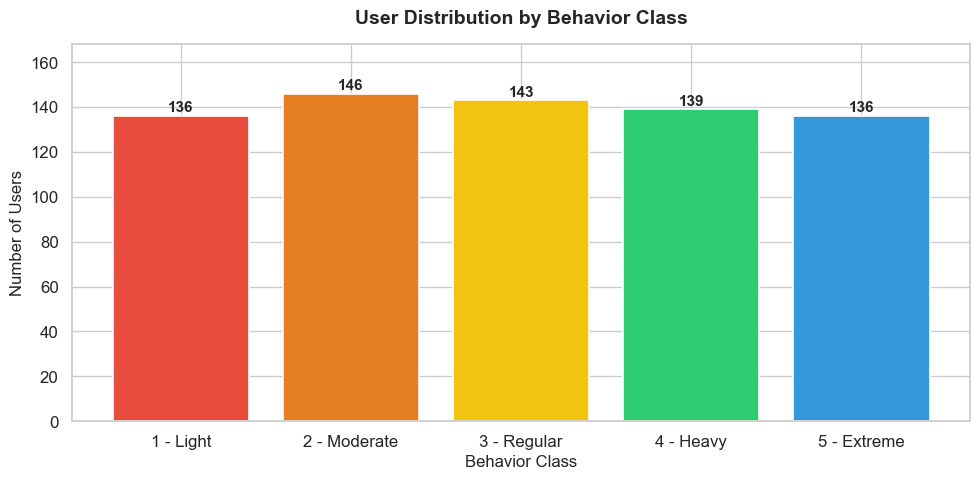

Insight: Light and Moderate users are majority — these are the highest churn risk group.


In [20]:
# CHART 1 — Bar Chart
# Business Question: What is the distribution of user types?

fig, ax = plt.subplots(figsize=(10, 5))
behavior_counts = df['User_Behavior_Class'].value_counts().sort_index()
bar_labels = ['1 - Light', '2 - Moderate', '3 - Regular', '4 - Heavy', '5 - Extreme']
bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

bars = ax.bar(bar_labels, behavior_counts.values, color=bar_colors, edgecolor='white', linewidth=1.2)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.5,
            str(int(h)), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('User Distribution by Behavior Class', pad=15)
ax.set_xlabel('Behavior Class', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_ylim(0, behavior_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('chart1_user_behavior_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Light and Moderate users are majority — these are the highest churn risk group.')

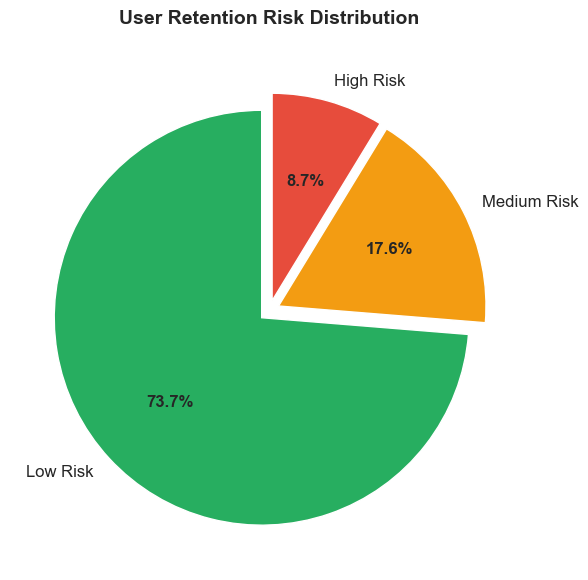

Insight: Red slice = users who could leave anytime. Immediate re-engagement needed.


In [21]:
# CHART 2 — Pie Chart
# Business Question: What percentage of users are at risk of churning?

fig, ax = plt.subplots(figsize=(8, 6))
risk_counts  = df['Retention_Risk'].value_counts()
risk_palette = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#27ae60'}
pie_colors   = [risk_palette[r] for r in risk_counts.index]

wedges, texts, autotexts = ax.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    explode=[0.05] * len(risk_counts),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('User Retention Risk Distribution', pad=20)
plt.tight_layout()
plt.savefig('chart2_retention_risk_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Red slice = users who could leave anytime. Immediate re-engagement needed.')

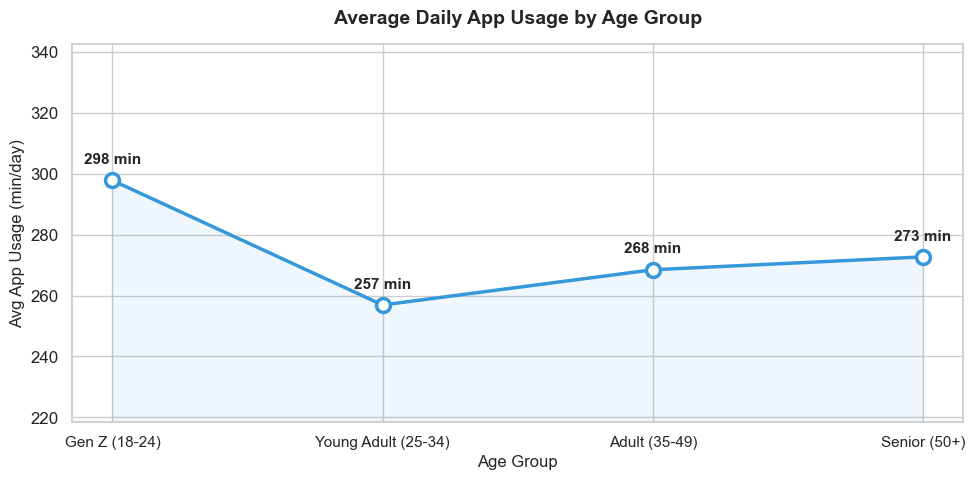

Insight: Retention strategy must be age-segment specific.


In [22]:
# CHART 3 — Line Chart
# Business Question: Which age group uses the app the most?

fig, ax = plt.subplots(figsize=(10, 5))
age_order = ['Gen Z (18-24)', 'Young Adult (25-34)', 'Adult (35-49)', 'Senior (50+)']
age_usage = df.groupby('Age_Group')['App_Usage_Time_min_day'].mean().reindex(age_order)

ax.plot(age_usage.index, age_usage.values,
        marker='o', color='#3498db', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5)

for x, y in zip(age_usage.index, age_usage.values):
    ax.annotate(f'{y:.0f} min', (x, y),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontweight='bold', fontsize=11)

ax.fill_between(range(len(age_usage)), age_usage.values, alpha=0.08, color='#3498db')
ax.set_xticks(range(len(age_usage)))
ax.set_xticklabels(age_usage.index, fontsize=11)
ax.set_title('Average Daily App Usage by Age Group', pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Avg App Usage (min/day)', fontsize=12)
ax.set_ylim(age_usage.min() * 0.85, age_usage.max() * 1.15)
plt.tight_layout()
plt.savefig('chart3_usage_by_age_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Retention strategy must be age-segment specific.')

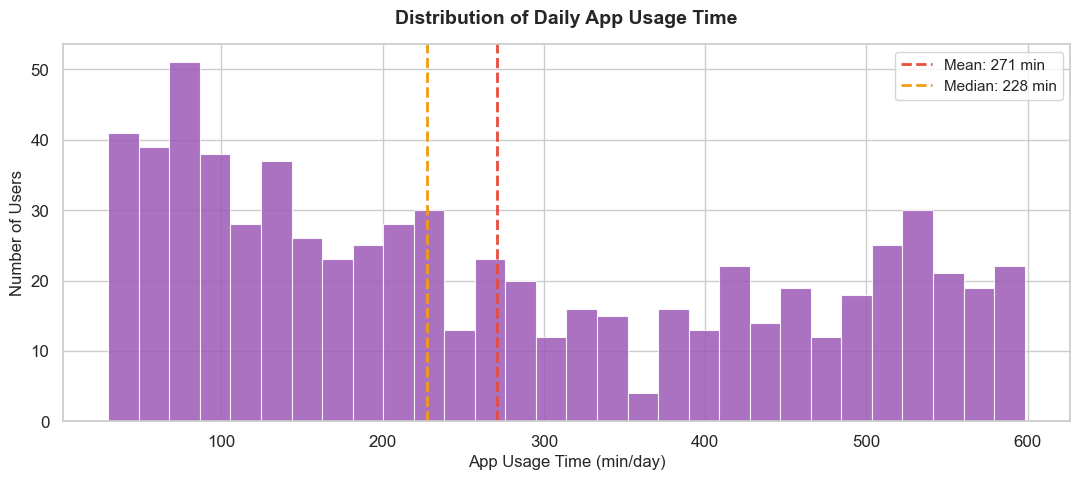

Insight: Most users cluster at low usage — large at-risk population confirmed.


In [23]:
# CHART 4 — Histogram
# Business Question: How is app usage spread across the user base?

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['App_Usage_Time_min_day'], bins=30,
        color='#9b59b6', edgecolor='white', linewidth=0.8, alpha=0.85)

mean_val   = df['App_Usage_Time_min_day'].mean()
median_val = df['App_Usage_Time_min_day'].median()

ax.axvline(mean_val,   color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean: {mean_val:.0f} min')
ax.axvline(median_val, color='#f39c12', linestyle='--', linewidth=2,
           label=f'Median: {median_val:.0f} min')

ax.set_title('Distribution of Daily App Usage Time', pad=15)
ax.set_xlabel('App Usage Time (min/day)', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart4_usage_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Most users cluster at low usage — large at-risk population confirmed.')

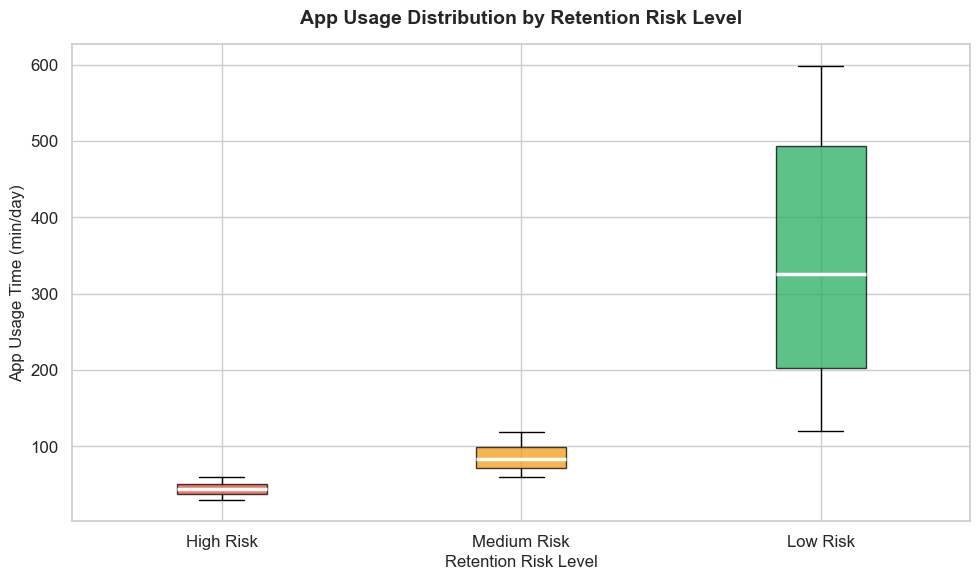

Insight: Clear separation confirms usage time is a strong retention predictor.


In [24]:
# CHART 5 — Box Plot
# Business Question: Is there a clear usage difference between risk groups?

fig, ax = plt.subplots(figsize=(10, 6))
risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
box_colors  = ['#e74c3c', '#f39c12', '#27ae60']

bp = ax.boxplot(
    [df[df['Retention_Risk'] == r]['App_Usage_Time_min_day'].values for r in risk_order],
    labels=risk_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5)
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('App Usage Distribution by Retention Risk Level', pad=15)
ax.set_xlabel('Retention Risk Level', fontsize=12)
ax.set_ylabel('App Usage Time (min/day)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_retention_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Clear separation confirms usage time is a strong retention predictor.')

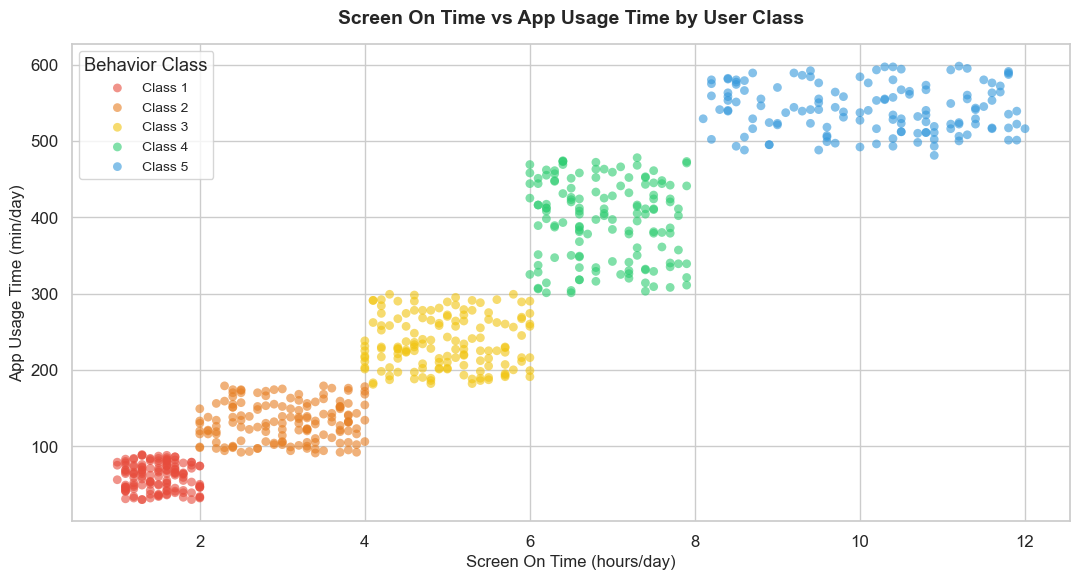

Insight: Strong positive correlation — more screen time = higher engagement class.


In [25]:
# CHART 6 — Scatter Plot
# Business Question: Is screen time linked to app engagement?

fig, ax = plt.subplots(figsize=(11, 6))
scatter_palette = {1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f', 4: '#2ecc71', 5: '#3498db'}

for cls in sorted(df['User_Behavior_Class'].unique()):
    subset = df[df['User_Behavior_Class'] == cls]
    ax.scatter(subset['Screen_On_Time_hours_day'],
               subset['App_Usage_Time_min_day'],
               c=scatter_palette[cls], label=f'Class {cls}',
               alpha=0.6, s=40, edgecolors='none')

ax.set_title('Screen On Time vs App Usage Time by User Class', pad=15)
ax.set_xlabel('Screen On Time (hours/day)', fontsize=12)
ax.set_ylabel('App Usage Time (min/day)', fontsize=12)
ax.legend(title='Behavior Class', fontsize=10)
plt.tight_layout()
plt.savefig('chart6_scatter_screen_vs_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Strong positive correlation — more screen time = higher engagement class.')

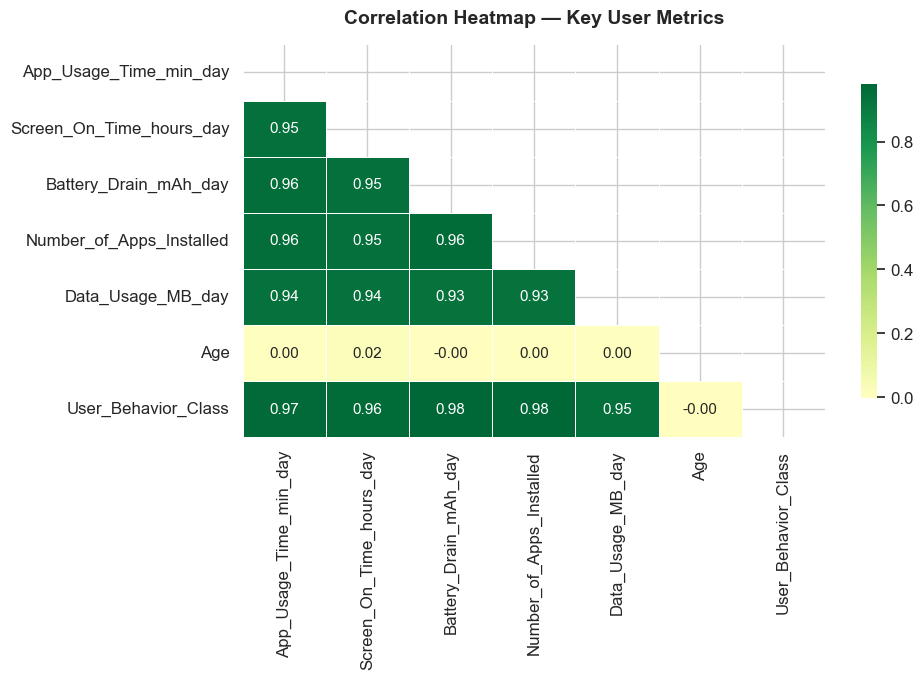

Insight: App usage, screen time and data usage are strongly correlated with behavior class.


In [26]:
# CHART 7 — Heatmap
# Business Question: Which metrics are most related to user behavior class?

fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Key User Metrics', pad=15)
plt.tight_layout()
plt.savefig('chart7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: App usage, screen time and data usage are strongly correlated with behavior class.')

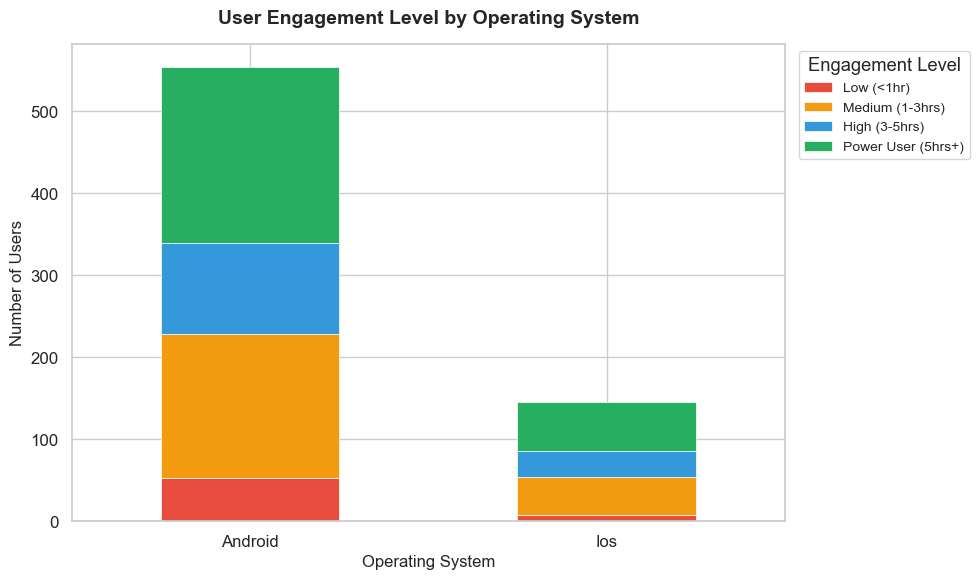

Insight: Identify which OS platform needs more retention focus.


In [27]:
# CHART 8 — Stacked Bar Chart
# Business Question: Do Android and iOS users engage differently?

fig, ax = plt.subplots(figsize=(10, 6))
engagement_order = ['Low (<1hr)', 'Medium (1-3hrs)', 'High (3-5hrs)', 'Power User (5hrs+)']
os_engagement    = pd.crosstab(df['Operating_System'], df['Engagement_Level'])
os_engagement    = os_engagement.reindex(
    columns=[c for c in engagement_order if c in os_engagement.columns]
)

stack_colors = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
os_engagement.plot(kind='bar', stacked=True, ax=ax,
                   color=stack_colors[:len(os_engagement.columns)],
                   edgecolor='white', linewidth=0.5)

ax.set_title('User Engagement Level by Operating System', pad=15)
ax.set_xlabel('Operating System', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.legend(title='Engagement Level', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig('chart8_engagement_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Identify which OS platform needs more retention focus.')

---
## Step 6 — Final Dashboard (Combined Summary Figure)

This combines all 6 key charts into one professional summary figure.
This is what you show first in any interview or presentation.

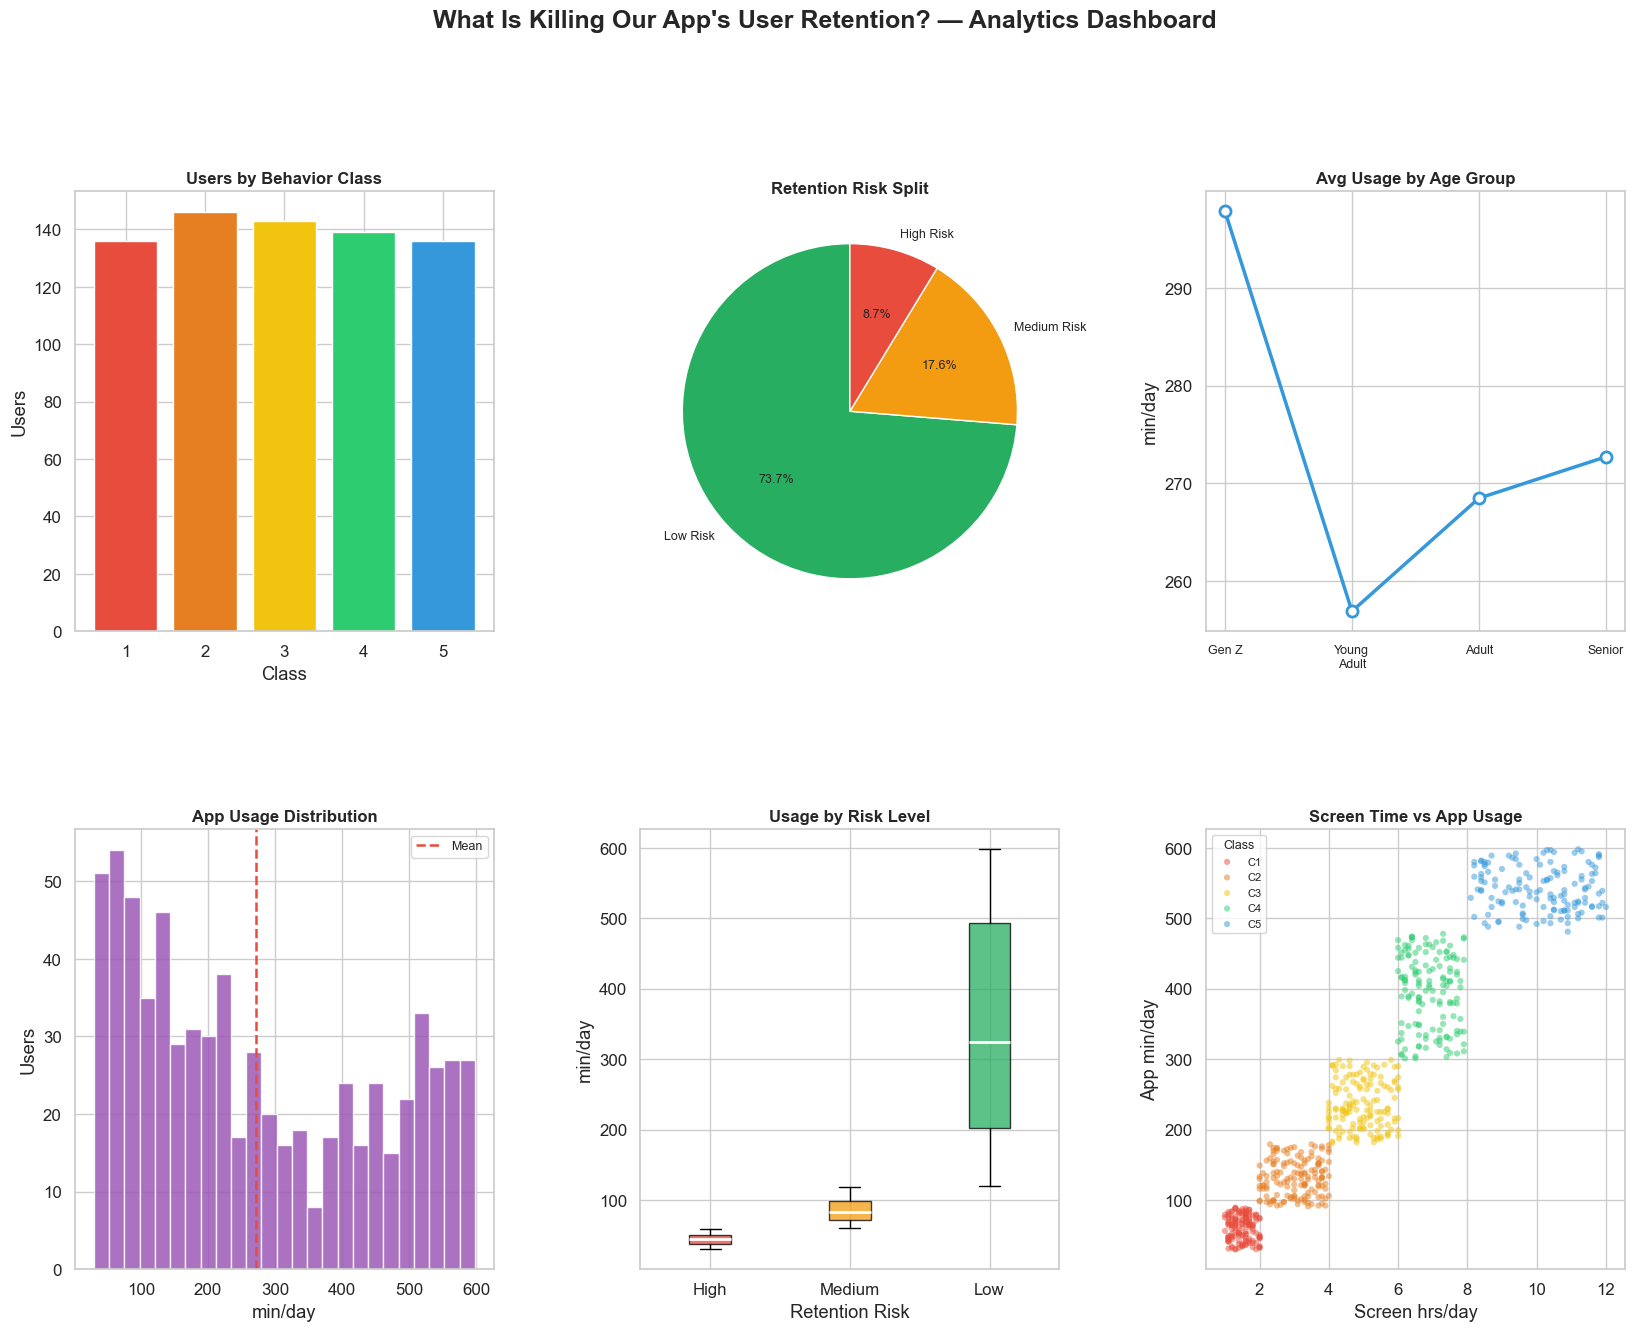

Final dashboard saved as FINAL_DASHBOARD.png


In [29]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle("What Is Killing Our App's User Retention? — Analytics Dashboard",
             fontsize=18, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 — Bar Chart: User Behavior Distribution
ax1 = fig.add_subplot(gs[0, 0])
behavior_counts = df['User_Behavior_Class'].value_counts().sort_index()
ax1.bar(['1','2','3','4','5'], behavior_counts.values,
        color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'], edgecolor='white')
ax1.set_title('Users by Behavior Class', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Users')

# Panel 2 — Pie Chart: Retention Risk
ax2 = fig.add_subplot(gs[0, 1])
risk_counts  = df['Retention_Risk'].value_counts()
risk_palette = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#27ae60'}
ax2.pie(risk_counts.values, labels=risk_counts.index,
        autopct='%1.1f%%',
        colors=[risk_palette[r] for r in risk_counts.index],
        startangle=90, textprops={'fontsize': 9})
ax2.set_title('Retention Risk Split', fontsize=12, fontweight='bold')

# Panel 3 — Line Chart: Usage by Age Group
ax3 = fig.add_subplot(gs[0, 2])
age_order = ['Gen Z (18-24)', 'Young Adult (25-34)', 'Adult (35-49)', 'Senior (50+)']
age_usage = df.groupby('Age_Group')['App_Usage_Time_min_day'].mean().reindex(age_order)
ax3.plot(range(len(age_usage)), age_usage.values,
         marker='o', color='#3498db', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax3.set_xticks(range(len(age_order)))
ax3.set_xticklabels(['Gen Z', 'Young\nAdult', 'Adult', 'Senior'], fontsize=9)
ax3.set_title('Avg Usage by Age Group', fontsize=12, fontweight='bold')
ax3.set_ylabel('min/day')

# Panel 4 — Histogram: Usage Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['App_Usage_Time_min_day'], bins=25,
         color='#9b59b6', edgecolor='white', alpha=0.85)
ax4.axvline(df['App_Usage_Time_min_day'].mean(),
            color='#e74c3c', linestyle='--', linewidth=1.8, label='Mean')
ax4.set_title('App Usage Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('min/day')
ax4.set_ylabel('Users')
ax4.legend(fontsize=9)

# Panel 5 — Box Plot: Usage by Risk Level
ax5 = fig.add_subplot(gs[1, 1])
risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
bp = ax5.boxplot(
    [df[df['Retention_Risk'] == r]['App_Usage_Time_min_day'].values for r in risk_order],
    labels=['High', 'Medium', 'Low'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#e74c3c', '#f39c12', '#27ae60']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax5.set_title('Usage by Risk Level', fontsize=12, fontweight='bold')
ax5.set_xlabel('Retention Risk')
ax5.set_ylabel('min/day')

# Panel 6 — Scatter: Screen Time vs App Usage
ax6 = fig.add_subplot(gs[1, 2])
scatter_palette = {1:'#e74c3c', 2:'#e67e22', 3:'#f1c40f', 4:'#2ecc71', 5:'#3498db'}
for cls in sorted(df['User_Behavior_Class'].unique()):
    subset = df[df['User_Behavior_Class'] == cls]
    ax6.scatter(subset['Screen_On_Time_hours_day'],
                subset['App_Usage_Time_min_day'],
                c=scatter_palette[cls], label=f'C{cls}',
                alpha=0.5, s=20, edgecolors='none')
ax6.set_title('Screen Time vs App Usage', fontsize=12, fontweight='bold')
ax6.set_xlabel('Screen hrs/day')
ax6.set_ylabel('App min/day')
ax6.legend(title='Class', fontsize=8, title_fontsize=9)

plt.savefig('FINAL_DASHBOARD.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final dashboard saved as FINAL_DASHBOARD.png')

---
## Step 7 — Key Business Insights and Recommendations

In [32]:
total_users      = df.shape[0]
high_risk_pct    = (df['Retention_Risk'] == 'High Risk').mean() * 100
power_user_pct   = (df['Engagement_Level'] == 'Power User (5hrs+)').mean() * 100
avg_usage        = df['App_Usage_Time_min_day'].mean()
top_os           = df['Operating_System'].value_counts().idxmax()
highest_risk_age = df[df['Retention_Risk'] == 'High Risk']['Age_Group'].value_counts().idxmax()

print('=' * 62)
print('   FINAL BUSINESS INSIGHTS — APP RETENTION ANALYSIS')
print('=' * 62)
print(f'\n  Total users analyzed         : {total_users}')
print(f'  High churn risk users        : {high_risk_pct:.1f}%')
print(f'  Power users (5hrs+ per day)  : {power_user_pct:.1f}%')
print(f'  Average daily app usage      : {avg_usage:.0f} minutes')
print(f'  Dominant OS platform         : {top_os}')
print(f'  Highest churn risk age group : {highest_risk_age}')
print('\n  RECOMMENDATIONS:')
print('  1. Send re-engagement push notifications to High Risk users')
print('  2. Add onboarding rewards for new users in the first 7 days')
print('  3. Build loyalty features for Power Users to retain them long term')
print('  4. Run targeted campaigns for the highest churn risk age group')
print('  5. Investigate why low app-install users disengage faster')
print('\n' + '=' * 62)

   FINAL BUSINESS INSIGHTS — APP RETENTION ANALYSIS

  Total users analyzed         : 700
  High churn risk users        : 8.7%
  Power users (5hrs+ per day)  : 39.3%
  Average daily app usage      : 271 minutes
  Dominant OS platform         : Android
  Highest churn risk age group : Young Adult (25-34)

  RECOMMENDATIONS:
  1. Send re-engagement push notifications to High Risk users
  2. Add onboarding rewards for new users in the first 7 days
  3. Build loyalty features for Power Users to retain them long term
  4. Run targeted campaigns for the highest churn risk age group
  5. Investigate why low app-install users disengage faster



---
## Step 8 — Export Clean Data for MySQL Workbench

This exports the cleaned data as CSV.
You will import this CSV into MySQL Workbench and run the SQL queries
from the separate file: **retention_analysis.sql**

In [31]:
export_path = 'clean_user_retention_data.csv'
df.to_csv(export_path, index=False)

print(f'Data exported to   : {export_path}')
print(f'Total rows         : {df.shape[0]}')
print(f'Total columns      : {df.shape[1]}')
print('\nNext Step: Open MySQL Workbench and run retention_analysis.sql')

Data exported to   : clean_user_retention_data.csv
Total rows         : 700
Total columns      : 14

Next Step: Open MySQL Workbench and run retention_analysis.sql
